In [14]:
import numpy as np
import numpy as np
import scipy.stats as stats
import math

def compute_ci(data, alpha = 0.05):
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof = 1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df = n-1)
    lower = mean - t_crit * std_err
    upper = mean + t_crit *std_err
    return mean, lower, upper


# Part 1

In [ ]:
from scipy.special import factorial 
m = 10
mean_time = 1
mean_service = 8
n_reps = 10
n_customers = 10000


m = 10
lambda_ = 1
mean_service = 8

A = lambda_*mean_service

n_iterations = 10_000

np.random.seed(42)


def MCMC(n, m, A):
    states = np.zeros(n, dtype = int)
    current_state = 0
    alpha = 0

    for k in range(n):
        # step choice?
        step = np.random.choice([-1,1])
        prop_step = current_state + step
        r = 0

        if 0 <= prop_step <= m:
            if step == 1:
                r = A/( current_state + 1 )

            else:
                r = current_state/A
        
        alpha = min(1, r)
        
        if np.random.rand() < alpha:
            current_state = prop_step

        states[k] = current_state 

    return states


burn_in = 100
sim_states = MCMC(n_iterations, m, A)[burn_in:]

observed = np.bincount(sim_states, minlength=m+1)

i_vals = np.arange(m + 1)
theo_weights = (A**i_vals) / factorial(i_vals)
p = theo_weights / theo_weights.sum()

effective_n = n_iterations - burn_in
expected = effective_n * p

chi2_stat, p_value = stats.chisquare(observed, expected)

print("Observed counts:", observed)
print("Expected counts:", np.round(expected, 1))
print(f"Chi2 Statistic: {chi2_stat:.4f}, p-value: {p_value:.4f}")

Observed counts: [  10   19  127  346  695 1118 1509 1730 1685 1500 1161]
Expected counts: [   4.1   32.6  130.3  347.4  694.7 1111.5 1482.  1693.8 1693.8 1505.6
 1204.4]
Chi2 Statistic: 17.3112, p-value: 0.0678


# Part 2

In [42]:
A1 = 4
A2 = 4
m = 10

n_iterations = 10_000

np.random.seed(42)

def target(i, j):
    if i < 0 or j < 0 or (i + j) > m:
        return 0
    return (pow(A1, i) / math.factorial(i)) * (pow(A2, j) / math.factorial(j))


def MCMC_2d(n, m):
    states = np.zeros((n, 2), dtype = int)
    current_state_i = 0
    current_state_j = 0
    alpha = 0
    i, j = 0, 0

    for k in range(n):
        # step choice?
        step_i = np.random.choice([-1,0,1])
        step_j = np.random.choice([-1,0,1])
        prop_step_i = current_state_i + step_i
        prop_step_j = current_state_j + step_j
        r = 0


        w_proposed = target(prop_step_i, prop_step_j)
        w_current = target(current_state_i, current_state_j)

        r = w_proposed/w_current
        
        alpha = min(1, r)
        
        if np.random.rand() < alpha:
            current_state_i, current_state_j = prop_step_i, prop_step_j

        states[k] = [current_state_i, current_state_j]

    return states

burn_in = 100
thinning_step = 10

# 1. Run the simulation
raw_states = MCMC_2d(n_iterations, m)

# 2. Apply Burn-in AND Thinning
# [burn_in::thinning_step] starts after burn-in and grabs every 5th element
sim_states = raw_states[burn_in::thinning_step]

# 3. For the 1D Chi-Square test, compute total occupancy (i + j) per sample
total_occupancy = sim_states.sum(axis=1)
observed = np.bincount(total_occupancy, minlength=m+1)

# 4. Calculate 1D Theoretical Distribution (Erlang-B for total load A = A1 + A2)
A_total = A1 + A2
i_vals = np.arange(m + 1)
theo_weights = (A_total**i_vals) / factorial(i_vals)
p = theo_weights / theo_weights.sum()

# Expected counts based on post-thinning, post-burn-in sample size
effective_n = len(total_occupancy)
expected = effective_n * p

# 5. Perform Chi-square goodness-of-fit test
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"Total samples retained after thinning: {effective_n}")
print("Observed total occupancy:", observed)
print("Expected total occupancy:", np.round(expected, 1))
print(f"Chi2 Statistic: {chi2_stat:.4f}, p-value: {p_value:.4f}")

Total samples retained after thinning: 990
Observed total occupancy: [  0   2  10  33  90 111 141 168 171 154 110]
Expected total occupancy: [  0.4   3.3  13.   34.7  69.5 111.2 148.2 169.4 169.4 150.6 120.4]
Chi2 Statistic: 9.1098, p-value: 0.5217


In [ ]:
A1 = 4
A2 = 4
m = 10

n_iterations = 10_000

np.random.seed(42)

def target(i, j):
    if i < 0 or j < 0 or (i + j) > m:
        return 0
    return (pow(A1, i) / math.factorial(i)) * (pow(A2, j) / math.factorial(j))


def MCMC_2d(n, m):
    states = np.zeros((n, 2), dtype = int)
    current_state_i = 0
    current_state_j = 0
    alpha = 0
    i, j = 0, 0

    for k in range(n):
        step_i = np.random.choice([-1,0,1])
        prop_step_i = current_state_i + step_i

        wp_i = target(prop_step_i, current_state_j)
        wc_i = target(current_state_i, current_state_j)

        r_i = wp_i/wc_i

        alpha_i = min(1,r_i)

        if np.random.rand() < alpha_i:
            current_state_i = prop_step_i

        step_j = np.random.choice([-1,0,1])
        prop_step_j = current_state_j + step_j

        wp_j = target(current_state_i, prop_step_j)
        wc_j = target(current_state_i, current_state_j)

        r_j = wp_j/wc_j

        alpha_j = min(1,r_j)

        if np.random.rand() < alpha_j:
            current_state_j = prop_step_j
        

        states[k] = [current_state_i, current_state_j]

    return states

burn_in = 100
thinning_step = 10

# 1. Run the simulation
raw_states = MCMC_2d(n_iterations, m)

# 2. Apply Burn-in AND Thinning
# [burn_in::thinning_step] starts after burn-in and grabs every 5th element
sim_states = raw_states[burn_in::thinning_step]

# 3. For the 1D Chi-Square test, compute total occupancy (i + j) per sample
total_occupancy = sim_states.sum(axis=1)
observed = np.bincount(total_occupancy, minlength=m+1)

# 4. Calculate 1D Theoretical Distribution (Erlang-B for total load A = A1 + A2)
A_total = A1 + A2
i_vals = np.arange(m + 1)
theo_weights = (A_total**i_vals) / factorial(i_vals)
p = theo_weights / theo_weights.sum()

# Expected counts based on post-thinning, post-burn-in sample size
effective_n = len(total_occupancy)
expected = effective_n * p

# 5. Perform Chi-square goodness-of-fit test
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"Total samples retained after thinning: {effective_n}")
print("Observed total occupancy:", observed)
print("Expected total occupancy:", np.round(expected, 1))
print(f"Chi2 Statistic: {chi2_stat:.4f}, p-value: {p_value:.4f}")

Total samples retained after thinning: 990
Observed total occupancy: [  0   6  16  49  64 122 157 162 171 146  97]
Expected total occupancy: [  0.4   3.3  13.   34.7  69.5 111.2 148.2 169.4 169.4 150.6 120.4]
Chi2 Statistic: 16.3055, p-value: 0.0912


In [46]:
A1 = 4
A2 = 4
m = 10

n_iterations = 10_000

np.random.seed(42)

def target(i, j):
    if i < 0 or j < 0 or (i + j) > m:
        return 0
    return (pow(A1, i) / math.factorial(i)) * (pow(A2, j) / math.factorial(j))


def gibbs(n):
    states = np.zeros((n, 2), dtype = int)
    current_state_i = 0
    current_state_j = 0


    for k in range(n):
        max_i = m - current_state_j
        w_i = np.array([pow(A1, x) / math.factorial(x) for x in range(max_i + 1)])
        prob_step_i = w_i / np.sum(w_i)

        current_state_i = np.random.choice(len(prob_step_i), p=prob_step_i)

        max_j = m - current_state_i
        w_j = np.array([pow(A1, x) / math.factorial(x) for x in range(max_j + 1)])
        prob_step_j = w_j / np.sum(w_j)

        current_state_j = np.random.choice(len(prob_step_j), p=prob_step_j)
        

        states[k] = [current_state_i, current_state_j]

    return states

burn_in = 100
thinning_step = 10

# 1. Run the simulation
raw_states = gibbs(n_iterations)

# 2. Apply Burn-in AND Thinning
# [burn_in::thinning_step] starts after burn-in and grabs every 5th element
sim_states = raw_states[burn_in::thinning_step]

# 3. For the 1D Chi-Square test, compute total occupancy (i + j) per sample
total_occupancy = sim_states.sum(axis=1)
observed = np.bincount(total_occupancy, minlength=m+1)

# 4. Calculate 1D Theoretical Distribution (Erlang-B for total load A = A1 + A2)
A_total = A1 + A2
i_vals = np.arange(m + 1)
theo_weights = (A_total**i_vals) / factorial(i_vals)
p = theo_weights / theo_weights.sum()

# Expected counts based on post-thinning, post-burn-in sample size
effective_n = len(total_occupancy)
expected = effective_n * p

# 5. Perform Chi-square goodness-of-fit test
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"Total samples retained after thinning: {effective_n}")
print("Observed total occupancy:", observed)
print("Expected total occupancy:", np.round(expected, 1))
print(f"Chi2 Statistic: {chi2_stat:.4f}, p-value: {p_value:.4f}")

Total samples retained after thinning: 990
Observed total occupancy: [  1   3  13  40  60 145 135 157 173 149 114]
Expected total occupancy: [  0.4   3.3  13.   34.7  69.5 111.2 148.2 169.4 169.4 150.6 120.4]
Chi2 Statistic: 15.7990, p-value: 0.1055


# Part 3

In [51]:
rho = 1/2

np.random.seed(42)
Z1 = np.random.normal(0,1)
Z2 = np.random.normal(0,1)

xi = Z1
gamma = rho * Z1 + np.sqrt(1 - rho**2) * Z2

theta_0 = np.exp(xi)
psi_0 = np.exp(gamma)

theta_0, psi_0


(np.float64(1.6433127155860012), np.float64(1.1372541075120601))

In [53]:
n = 10

data = np.random.normal(loc=theta_0, scale=np.sqrt(psi_0), size=n)

data

array([ 1.9013464 , -0.39704984, -0.19617617,  1.04367739,  0.56320817,
        1.97843272,  0.67497662,  0.13720215,  3.20631159,  1.40254009])

In [55]:
x_bar = np.mean(data)
s_sq = np.var(data, ddof = 1)

def log_posterior(psi, theta):
    if psi <= 0 or theta <= 0:
        return -np.inf
    
    log_like = (-n / 2.0) * np.log(psi) - (
        ((n - 1) * s_sq + n * (x_bar - theta) ** 2) / (2.0 * psi)
    )

    log_prior = -np.log(theta) - np.log(psi) - (
        (np.log(theta) ** 2 - 2 * rho * np.log(theta) * np.log(psi) + np.log(psi) ** 2)
        / (2.0 * (1 - rho**2))
    )

    return log_like + log_prior

log_posterior(psi_0, theta_0)

np.float64(-7.978077618188387)

In [56]:
def metropolis_hastings(n):
    samples = np.zeros((n, 2))

    current_theta = 1
    current_psi = 1

    prop_std_theta = 0.2
    prop_std_psi = 0.2

    for k in range(n):
        prop_theta = current_theta + np.random.normal(0, prop_std_theta)
        prop_psi = current_psi + np.random.normal(0,prop_std_psi)

        log_w_prop = log_posterior(prop_psi, prop_theta)
        log_w_curr = log_posterior(current_psi, current_theta)

        log_alpha = log_w_prop - log_w_curr

        if np.log(np.random.rand()) < log_alpha:
            current_theta = prop_theta
            current_psi = prop_psi

        samples[k] = [current_theta, current_psi]
    
    return samples

In [61]:
mcmc_steps = 20_000

burn_in = int(mcmc_steps * 0.2)

for sample_size in [10, 100, 1000, 10000]:
    loop_data = np.random.normal(loc = theta_0, scale= np.sqrt(psi_0), size = sample_size)

    x_bar = np.mean(loop_data)
    s_sq = np.var(loop_data, ddof=1)
    n = sample_size

    chain = metropolis_hastings(mcmc_steps)
    clean_chain = chain[burn_in:]

    est_theta = np.mean(clean_chain[:,0])
    est_psi = np.mean(clean_chain[:,1])

    print(f"\nResults for n = {sample_size}:")
    print(f"  Estimated Theta: {est_theta:.4f} (True: {theta_0:.4f})")
    print(f"  Estimated Psi:   {est_psi:.4f} (True: {psi_0:.4f})")


Results for n = 10:
  Estimated Theta: 1.8746 (True: 1.6433)
  Estimated Psi:   1.1593 (True: 1.1373)

Results for n = 100:
  Estimated Theta: 1.6376 (True: 1.6433)
  Estimated Psi:   1.1416 (True: 1.1373)

Results for n = 1000:
  Estimated Theta: 1.6120 (True: 1.6433)
  Estimated Psi:   1.1553 (True: 1.1373)

Results for n = 10000:
  Estimated Theta: 1.6218 (True: 1.6433)
  Estimated Psi:   1.1404 (True: 1.1373)


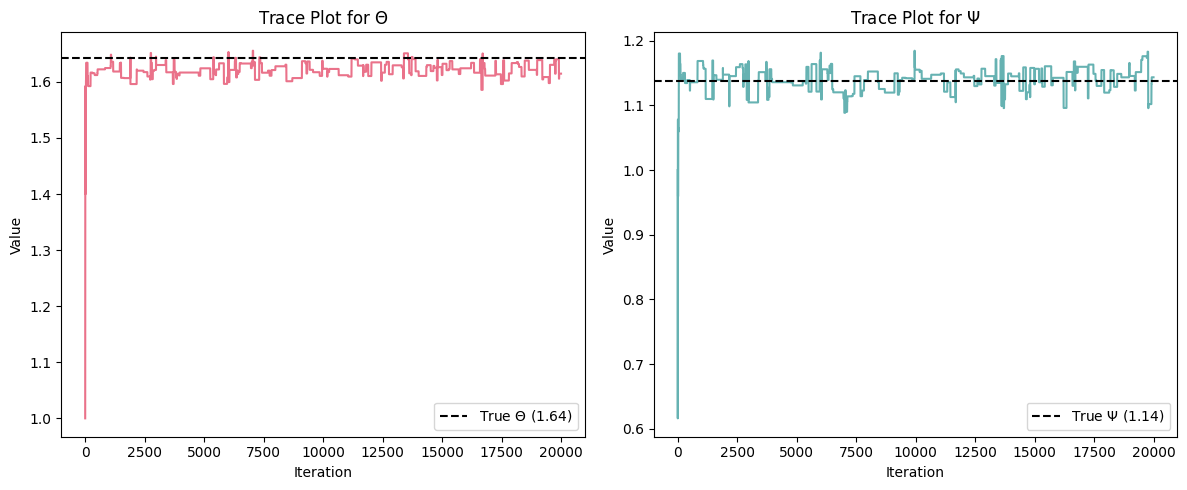

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Theta Trace
plt.subplot(1, 2, 1)
plt.plot(chain[:, 0], color='crimson', alpha=0.6)
plt.axhline(theta_0, color='black', linestyle='--', label=f'True $\Theta$ ({theta_0:.2f})')
plt.title('Trace Plot for $\Theta$')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()

# Psi Trace
plt.subplot(1, 2, 2)
plt.plot(chain[:, 1], color='teal', alpha=0.6)
plt.axhline(psi_0, color='black', linestyle='--', label=f'True $\Psi$ ({psi_0:.2f})')
plt.title('Trace Plot for $\Psi$')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()